In [9]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random
     

In [10]:

X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [11]:

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.786235,-1.816878,0.801392,0.818589,1.007256,0
1,-2.470248,-1.506082,2.656424,0.602642,1.589698,0
2,0.012738,2.833134,-1.126663,-0.118041,1.876463,0
3,0.876484,-1.154274,1.192288,1.135983,0.425423,1
4,1.463934,0.628632,0.473546,0.415537,2.765103,1


In [12]:

# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [13]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [14]:

# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [15]:
df1 = combined_sampling(df,0.5,0.5)

In [16]:

df2 = combined_sampling(df,0.5,0.5)

In [17]:

df3 = combined_sampling(df,0.5,0.5)

In [18]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col3', 'target'], dtype='str')
Index(['col1', 'col5', 'target'], dtype='str')
Index(['col4', 'col2', 'target'], dtype='str')


In [19]:

df3

,col4,col2,target
71,2.366343,-2.047113,1
92,-1.972142,1.286736,0
75,1.768403,1.190068,0
80,-0.140602,1.817404,0
51,1.049883,-0.847444,1
23,1.037722,-0.025282,1
5,-1.266892,-0.345090,1
85,-0.113790,-1.324999,1
76,-0.024018,1.270206,0
32,0.045202,-2.326158,1


In [20]:

from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [21]:

clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.3333333333333333, 0.95, 'x[1] <= 0.316\ngini = 0.48\nsamples = 50\nvalue = [20, 30]'),
 Text(0.2222222222222222, 0.85, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.2777777777777778, 0.8999999999999999, 'True  '),
 Text(0.4444444444444444, 0.85, 'x[1] <= 2.25\ngini = 0.422\nsamples = 43\nvalue = [13, 30]'),
 Text(0.38888888888888884, 0.8999999999999999, '  False'),
 Text(0.3333333333333333, 0.75, 'x[0] <= 1.573\ngini = 0.332\nsamples = 38\nvalue = [8, 30]'),
 Text(0.2222222222222222, 0.65, 'x[0] <= 0.155\ngini = 0.472\nsamples = 21\nvalue = [8, 13]'),
 Text(0.1111111111111111, 0.55, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.3333333333333333, 0.55, 'x[1] <= 0.738\ngini = 0.49\nsamples = 14\nvalue = [8, 6]'),
 Text(0.2222222222222222, 0.45, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4444444444444444, 0.45, 'x[1] <= 1.101\ngini = 0.397\nsamples = 11\nvalue = [8, 3]'),
 Text(0.3333333333333333, 0.35, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.55555

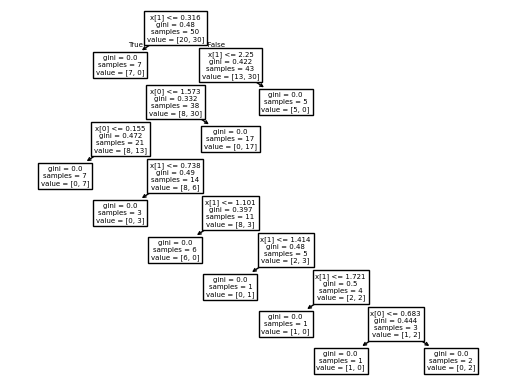

In [22]:
from sklearn.tree import plot_tree
     

plot_tree(clf1)

[Text(0.5, 0.9166666666666666, 'x[0] <= 0.135\ngini = 0.471\nsamples = 50\nvalue = [19, 31]'),
 Text(0.3333333333333333, 0.75, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.41666666666666663, 0.8333333333333333, 'True  '),
 Text(0.6666666666666666, 0.75, 'x[1] <= 1.043\ngini = 0.114\nsamples = 33\nvalue = [2, 31]'),
 Text(0.5833333333333333, 0.8333333333333333, '  False'),
 Text(0.5, 0.5833333333333334, 'x[1] <= 0.898\ngini = 0.188\nsamples = 19\nvalue = [2, 17]'),
 Text(0.3333333333333333, 0.4166666666666667, 'x[1] <= 0.088\ngini = 0.105\nsamples = 18\nvalue = [1, 17]'),
 Text(0.16666666666666666, 0.25, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.5, 0.25, 'x[1] <= 0.296\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.3333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.08333333333333333, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.6666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nval

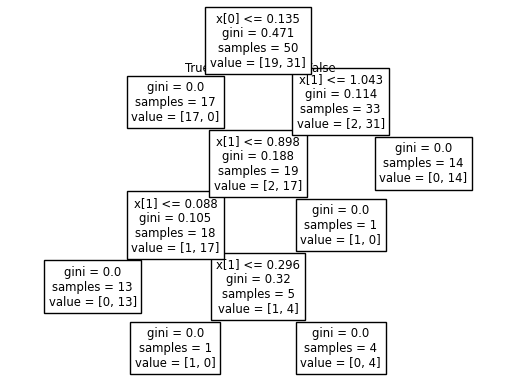

In [23]:

plot_tree(clf2)

[Text(0.6, 0.9, 'x[1] <= 0.68\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.5, 0.7, 'x[0] <= -0.63\ngini = 0.225\nsamples = 31\nvalue = [4, 27]'),
 Text(0.55, 0.8, 'True  '),
 Text(0.2, 0.5, 'x[1] <= -0.512\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3, 0.3, 'x[0] <= -1.588\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.5, 'x[0] <= -0.032\ngini = 0.074\nsamples = 26\nvalue = [1, 25]'),
 Text(0.7, 0.3, 'x[0] <= -0.112\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]'),
 Text(0.7, 0.7, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]'),
 Text(0.6499999999999999, 0.8, '  False')]

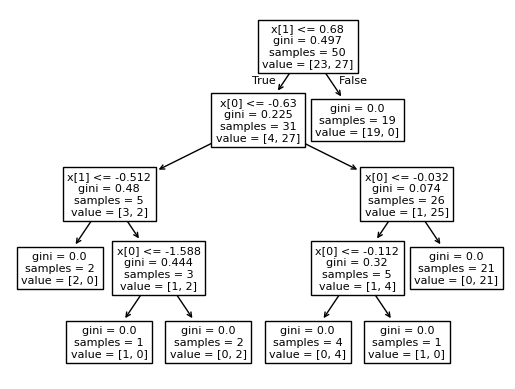

In [24]:

plot_tree(clf3)

In [25]:

clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [26]:

clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))
     

c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [27]:

clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\nic\Desktop\aiy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [29]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
80,-0.455328,1.817404,-1.681344,-0.140602,0.401875,0
69,1.466207,0.369403,0.382583,1.441278,-0.144914,1
4,1.463934,0.628632,0.473546,0.415537,2.765103,1
82,1.558778,0.584411,0.626386,0.338546,0.429181,1
17,-0.989728,1.373155,0.788071,-1.603084,0.298986,0
75,-1.236249,1.190068,-1.164421,1.768403,2.350408,0
97,1.352197,0.806350,0.884306,0.109516,1.131397,1
34,0.393050,-0.922345,0.779041,1.564926,3.340642,1
99,-0.558639,0.497501,1.966343,-1.909011,0.551321,0
88,0.649870,-1.114080,0.467179,2.056261,1.261633,1
